In [ ]:
from langchain_groq import ChatGroq
import os
os.getenv('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = ''

llm = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

'''
Chain Of Thought
 - step by step
Tree Of Thought
 -  tree structure
Graph Of Thought
-   complex problem


ReAct-> Think-> Act-> Observe->Repeat
'''

In [7]:
# CoT- step by step reasoning
# problem-> Step1 -> step2-> final answer
'''
start
|
think - llm   problem-> step by step.
|
answer - llm - response(steps to solve) - final answer
'''

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from langchain_core.tools import tool
from typing import TypedDict

class State(TypedDict):
  question: str
  reasoning : str
  answer: str

# CoT reasoning
def think(state: State):
  prompt=f'''
Solve in step by step:

Question: {state["question"]}

Explain your reasoning clearly.
  '''
  response= llm.invoke(prompt)
  state["reasoning"] = response.content
  return state

def answer(state: State):
  prompt=f"""
Based on the reasoning:
{state["reasoning"]}

Give me the final answer .

  """
  response=llm.invoke(prompt)
  state["answer"] = response.content
  return state

builder= StateGraph(State)
builder.add_node("think",think)
builder.add_node("answer",answer)

builder.set_entry_point("think")
builder.add_edge("think","answer")

graph=builder.compile()

app = graph.invoke({"question":"What is 12 * 15 + 10?"})
print(app["reasoning"])
print(app["answer"])


To solve the expression 12 * 15 + 10, we need to follow the order of operations (PEMDAS):

1. **P**arentheses: There are no parentheses in this expression.
2. **E**xponents: There are no exponents in this expression.
3. **M**ultiplication and **D**ivision: We need to perform the multiplication operation first.
4. **A**ddition and **S**ubtraction: After multiplication, we will perform the addition operation.

Here are the steps:

1. Multiply 12 and 15:
   12 * 15 = ?

To multiply 12 and 15, we can use the multiplication chart or multiply the numbers together:
12 * 10 = 120
12 * 5 = 60
Add the results: 120 + 60 = 180

2. Add 10 to the result:
   180 + 10 = ?

To add 10 to 180, we simply add the numbers together:
180 + 10 = 190

So, the final answer is: 190.
The final answer is: 190.


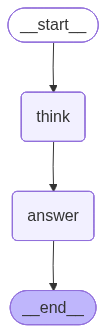

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

#ToT- Tree Of Thought
# CoT    -  Step1-> Step2 -> Step3-> Answer (single path)
#ToT
'''
    Thought1
    /       \
   Though2A  Thought2B
   /   \       /
  3A   3B     3C
    \  |     /
     evaluation---> best answer

    Path1--> 1-2A-3A   Path2-> 1-2A-3B    Path3-> 1-2B-3C

    start
/      |     \
Path1  Path2  Path3
\      \     /
    evaluate
      |
      final answer
start
|
generate_thought - llm -> generate 3 ways to solve problem
|
evaluate - llm - choose best answer
|
answer - llm - final answer

'''

In [11]:
class State(TypedDict):
  question:str
  thoughts: str
  best: str

# generate_thought
def generate_thoughts(state: State):
  prompt=f"""

  Give 3 diffrent ways to solve the question:
  {state["question"]}
  """
  res= llm.invoke(prompt)
  state["thoughts"] = res.content
  return state

# Evaluate - choose best
def evaluate(state: State):
  prompt=f"""
  Choose best reasoning:
  {state["thoughts"]}
  """
  res= llm.invoke(prompt)
  state["best"] = res.content
  return state

builder= StateGraph(State)
builder.add_node("generate_thoughts",generate_thoughts)
builder.add_node("evaluate",evaluate)

builder.set_entry_point("generate_thoughts")
builder.add_edge("generate_thoughts","evaluate")

graph=builder.compile()

print(graph.invoke({"question":"How to improve sales?"}))

builder.set_entry_point("generate_thoughts")
builder.add_edge("generate_thoughts","evaluate")

app = graph.invoke({"question":"How to improve sales?"})
print("Thoughts:\n" ,app["thoughts"])
print("Best : \n",app["best"])


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


{'question': 'How to improve sales?', 'thoughts': "Here are three different ways to improve sales:\n\n**Method 1: Analyzing and Optimizing the Sales Process**\n\n1. **Identify bottlenecks**: Analyze the sales process to identify areas where potential customers are dropping off or losing interest.\n2. **Streamline the process**: Simplify and shorten the sales process to make it more efficient and less intimidating for potential customers.\n3. **Improve communication**: Train sales representatives to effectively communicate the value proposition and address customer concerns.\n4. **Set clear goals and metrics**: Establish clear sales targets and metrics to measure progress and identify areas for improvement.\n5. **Continuously collect feedback**: Gather feedback from customers and sales representatives to make data-driven decisions and improve the sales process.\n\n**Method 2: Enhancing the Customer Experience**\n\n1. **Understand customer needs**: Conduct market research to understand c

#Graph Of Thought
' How to improve Healthcare system'
'''
start
|
patient_ flow   - patient entry- symptoms select- doctor appointment request   Ai_triage - patients_flow- symptom- appointment request
|                                                                                 |
|-----------------------------------scheduling------------------------------------|
                                       |
                                      Payment

'''

In [15]:
class State(TypedDict):
  input: str
  patient_flow: str
  scheduling: str
  payment: str
  ai_triage: str
  combined: str
  final:  str

#Node1 : Patient flow
def patient_flow(state: State):
  return {
      "patient_flow" : "Patient enters system -> selects "
  }

#Node2 : Scheduling
def scheduling(state: State):
  return{
    "scheduling": f"Smart scheduling system based on {state["patient_flow"]} + doctor availbility"
  }

#Node3 : Payment
def payment(state: State):
  return{
    "payment": "Integrated billing system combinig insurance and digital paymnents"
  }

#Node4 : AI Triage->patient_flow->appointment
def ai_triage(state: State):
  return{
    "ai_triage": f" AI analyzed symptoms from {state["patient_flow"]} and priotizes urgency"
  }

#Node 5 : Combines All Thoughts - Graph Merge Node
def combined(state: State):
  return{
      "combined":f"""
      Patient Flow:
      {state["patient_flow"]}

      Scheduling:
      {state["scheduling"]}

      Payment:
      {state["payment"]}

      AI Triage:
      {state["ai_triage"]}
      """
    }

#Node6: Feedback+refine
def refine(state: State):
  prompt = f"""
    Improve the healthcare system design
    {state["combined"]}
    Suggest improvements, remove inefficiences and make it scalable
    """
  response = llm.invoke(prompt)
  return {"final": response.content}

graph = StateGraph(State)

graph.add_node("patient_flow",patient_flow)
graph.add_node("scheduling",scheduling)
graph.add_node("payment",payment)
graph.add_node("ai_triage",ai_triage)
graph.add_node("combined",combined)
graph.add_node("refine",refine)

graph.set_entry_point("patient_flow")
graph.add_edge("patient_flow","scheduling")
graph.add_edge("patient_flow","ai_triage")
graph.add_edge("scheduling","payment")
graph.add_edge("ai_triage","payment")
graph.add_edge("payment","combined")
graph.add_edge("combined","refine")

graph.set_finish_point("refine")

app= graph.compile()
result= app.invoke(
      {
          "input": "Design a smart healthcare appointment system"
      }
  )
print(result["final"])





**Improved Healthcare System Design**

### Patient Flow

1. **Patient Registration and Profile Management**:
	* Implement a user-friendly patient registration process, allowing patients to create profiles and manage their information securely.
	* Integrate with electronic health records (EHRs) to ensure seamless access to patient data.
2. **Symptom Checker and AI-Powered Triage**:
	* Enhance the AI triage system to analyze symptoms, medical history, and vital signs to triage patients accurately and prioritize their needs.
	* Implement a symptom checker that provides patients with a list of potential conditions and recommendations for next steps.
3. **Virtual Waiting Room**:
	* Implement a virtual waiting room that allows patients to wait comfortably and access educational content, entertainment, or virtual consultations.
	* Integrate with the AI triage system to ensure patients are seen in order of priority.

### Scheduling

1. **Smart Scheduling Algorithm**:
	* Develop a smart schedul

ReAct - Thought-> Act-> Observe-> Thought->Act->Observe-> Repeat->final


ReAct-Thinking while Acting
VS
Advanced Planner- First think(plans)- Then Act(Executor)

Types:
     Simple Planner/ Static - task certain
     Dynamic Planner- plan can change
     Hierarchicial

LangGraph(Planner + Executor)

In [22]:
from typing import List

class State(TypedDict):
    input: str
    plan: List[str]
    step: int
    results: List[str]
    final: str

#planner
def planner(state: State):
    prompt = f"""
      Break the task into clear numbered steps
      Return ONLY steps, one per line.

      Task:
      {state["input"]}
      """

    res = llm.invoke(prompt).content
    #print(res)
    state["plan"] = res.split("\n")
    print(len(state['plan']))
    state["step"] = 0
    state["results"] = []
    return state

#Executor
def executor(state: State):
    step = state["plan"][state["step"]]
    result = llm.invoke(f"Execute{step}").content
    state["results"].append(result)
    state["step"]+=1
    print(state["step"])
    return state

def route(state: State):
    if state["step"] < len(state["plan"]):
        return "executor"
    return "final"

def final(state: State):
    state["final"] = "\n".join(state["results"])
    return state

builder = StateGraph(State)
builder.add_node("planner",planner)
builder.add_node("executor",executor)
builder.add_node("final",final)

builder.set_entry_point("planner")
builder.add_edge("planner","executor")

builder.add_conditional_edges(
    "executor",
    route,{
        "executor", "executor",
        "final","final"
    }
)

graph = builder.compile()
app = graph.invoke({"input":"Write about AI agents"})
print("Planner:\n",app["plan"])
print("Results:\n",app["final"])

10
1
2
3
4
5
6
7
8
9
10
Planner:
 ['1. Define the scope of AI agents and their applications.', '2. Explain the types of AI agents, including reactive, model-based, and goal-based.', '3. Discuss the characteristics of AI agents, such as deliberation, communication, and learning.', '4. Describe the difference between narrow and general AI agents.', '5. Discuss the strengths and limitations of AI agents in decision-making.', '6. Explain how AI agents can be used in real-world scenarios, such as customer service and navigation.', '7. Discuss the potential risks and challenges associated with AI agents, such as job displacement and bias.', '8. Outline the future directions and potential advancements in AI agent research and development.', '9. Provide examples of successful AI agents and their applications.', '10. Summarize the key points and takeaways from the discussion on AI agents.']
Results:
 **Scope of AI Agents and Their Applications**

An AI (Artificial Intelligence) agent is a softw

In [ ]:
#start
class State(TypedDict):
  input: str
  plan : List[str]
  step : int
  results: List[str]
  final: str

def planner(state: State):    # Static planner
  state["plan"] =[
      "Search for the Topic",
      "Summarize the content",
      "Write final answer"
  ]
  state["step"]=0
  state["result"]=[]
  return state


#Executor
def executor(state: State):

  if state["step"] >= len(state["plan"]):
    return state   # safe exit

  task=state["plan"][state["step"]]

  result=llm.invoke(task + ":" + state["input"])
  results1=result.content

  if "missing" in results1.lower():
    state["plan"].append("Add missing information")   # Dynamic Planner

  state["step"]+=1
  return state

def route(state: State):
  if state["step"] < len(state["plan"]):
    return "executor"
  return "end"


builder= StateGraph(State)
builder.add_node("planner",planner)
builder.add_node("executor",executor)


builder.set_entry_point("planner")
builder.add_edge("planner","executor")

builder.add_conditional_edges(
    "executor",
    route,
    {
        "executor": "executor",
        "end":"__end__"
    }
)
graph= builder.compile()
app=graph.invoke({"input":"Write about AI Agents"})
print(app)


{'input': 'Write about AI Agents', 'plan': ['Search for the Topic', 'Summarize the content', 'Write final answer'], 'step': 3}


In [ ]:
# Hierarchical Planner

from langgraph.graph import END

class State(TypedDict):
  input: str
  main_plan: List[str]
  sub_plan : List[str]
  step: int

# High level Planner

def main_planner(state: State) :
  res1=llm.invoke(state["input"])   # res= llm.invoke(f"Break into high level steps: {state["input"]}).content
  res= res1.content
  state["main_plan"]=res.split("\n")
  state["step"]=0
  return state

def sub_planner(state: State):
  task = state["main_plan"][state["step"]]   # res= llm.invoke(f"Break into smallersteps: {task}).content
  res1= llm.invoke(task)
  res= res1.content
  state["sub_plan"]=res.split("\n")
  return state

def executor(state: State):
  for s in state["sub_plan"]:
    res=llm.invoke(s)
    print(res.content)
  state["step"] +=1
  return state

def route(state : State):
    if state["step"] >= len(state["main_plan"]):
      return "end"
    return "sub_planner"

builder= StateGraph(State)
builder.add_node("main_planner",main_planner)
builder.add_node("sub_planner",sub_planner)
builder.add_node("executor",executor)

builder.set_entry_point("main_planner")
builder.add_edge("main_planner","sub_planner")
builder.add_edge("sub_planner","executor")

builder.add_conditional_edges(
    "executor",
    route,
    {
        "sub_planner": "sub_planner",
        "end":"__end__"
    }
)

graph = builder.compile()

result= graph.invoke({
    "input": "Write about AI Agents"
    })

print(result)

**Introduction to AI Agents**

Artificial Intelligence (AI) agents are software programs that can perceive their environment, make decisions, and take actions to achieve specific goals. They are the core of AI systems, allowing them to interact with users, other systems, and their surroundings. In this introduction, we'll cover the basics of AI agents, their types, and their applications.

### What is an AI Agent?

An AI agent is a software program that can:

1. **Perceive**: Gather information about its environment through sensors or user input.
2. **Reason**: Make decisions based on the perceived information and its knowledge base.
3. **Act**: Take actions to achieve its goals or respond to the environment.

### Types of AI Agents

There are several types of AI agents, classified based on their capabilities and behavior:

1. **Simple Reflex Agents**: Make decisions based on the current state of the environment.
2. **Model-Based Reflex Agents**: Use a model of the environment to make 

KeyboardInterrupt: 

ReAct - Reasoning Action
Types of Thoughts-CoT,ToT,GoT
Advanced Planner- strict, dynamic, hierarchical
Reflection Agent-  Think-> Answer-> Reflect -> Improve

In [ ]:
from langgraph.graph import END

class State(TypedDict):
 input: str
 answer: str
 feedback: str
 improved: str
 iteration: int

# Generate
def generate(state: State):
   res1=llm.invoke(state["input"])
   res=res1.content
   state["answer"]= res
   return state

# Reflect
def reflect(state: State):
  prompt= f"""
Critique this answer:
{state["answer"]}

  """
  res1= llm.invoke(prompt)
  res=res1.content
  state["feedback"]=res
  return state


#Improve
def improve(state: State):
  prompt=f"""
Improve answer based on feedback:
{state["answer"]}
{state["feedback"]}

  """

  res1=llm.invoke(prompt)
  res=res1.content
  state["improved"]=res
  state["iteration"] +=1
  return state

# Router
def route(state: State):
  if state["iteration"] < 3:
    return "reflect"
  return "end"


builder=StateGraph(State)
builder.add_node("generate",generate)
builder.add_node("reflect",reflect)
builder.add_node("improve",improve)

builder.set_entry_point("generate")
builder.add_edge("generate","reflect")
builder.add_edge("reflect","improve")

builder.add_conditional_edges(
    "improve",
    route,
    {
        "reflect": "reflect",
        "end":"__end__"
    }
)

graph= builder.compile()

app = graph.invoke({"input":"Write about AI Agents",
                    "iteration":0})
print("Input:\n",app["input"])
print("Answer:\n",app["answer"])
print("Feedback:\n",app["feedback"])
print("Improved:\n",app["improved"])


Input:
 Write about AI Agents
Answer:
 **Introduction to AI Agents**

Artificial Intelligence (AI) Agents are software entities that perform tasks on behalf of humans. They are designed to operate in a specific environment, interact with users, and make decisions based on their programming, data, and algorithms. AI Agents are a crucial component of the AI ecosystem, as they enable computers to perceive, reason, and act in the world.

**Types of AI Agents**

There are several types of AI Agents, including:

1. **Simple Reflex Agents**: These agents respond to their environment based on simple rules or conditions, without considering the long-term consequences of their actions.
2. **Model-Based Agents**: These agents use a model of the environment to plan and decide their actions. They can anticipate the outcomes of their actions and adjust their behavior accordingly.
3. **Goal-Based Agents**: These agents have a set of goals or objectives that they strive to achieve. They use planning a

Planning vs reflection

# langChain- RAG-
#Step 1: Load Doc from Datasource
#Step 2: Split Doc into chunks
#Step 3: Convert chunks to embeddings
#Step 4: Store in Vector DB

In [6]:
#Step 1: Load Doc from Datasource
from langchain_community.document_loaders import TextLoader
loader = TextLoader("my_docs.txt")
docs = loader.load()

#Step 2: Split Doc into chunks
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=100,chunk_overlap=20)
docs = text_splitter.split_documents(docs)

#Step 3: Convert chunks to embeddings
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#Step 4: Store in Vector DB
from langchain_community.vectorstores import FAISS
vector_store = FAISS.from_documents(docs,embedding_model)

#Step 5: Test similarity search
vector_store.similarity_search("langChain")

Created a chunk of size 291, which is longer than the specified 100
Created a chunk of size 112, which is longer than the specified 100
Created a chunk of size 868, which is longer than the specified 100
Created a chunk of size 490, which is longer than the specified 100
Created a chunk of size 858, which is longer than the specified 100
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8567.61it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Document(id='6f39157b-0db3-4329-85bf-d424aaede26a', metadata={'source': 'my_docs.txt'}, page_content='Core Components of LangChain\nLangChain breaks down complex AI workflows into modular, reusable building blocks.'),
 Document(id='f8d0ff3d-e30e-4adb-a0d8-809d59eca3a7', metadata={'source': 'my_docs.txt'}, page_content='LangChain is an open-source orchestration framework designed to simplify the creation of applications powered by Large Language Models (LLMs). It acts as a "bridge" or "glue," connecting raw AI models to external data, tools, and workflows to build context-aware, reasoning-capable systems.'),
 Document(id='f8565fe3-9a78-4e86-8889-90c2cc4804c4', metadata={'source': 'my_docs.txt'}, page_content='The LangChain Ecosystem\nBeyond the core library, the ecosystem includes specialized tools for the entire AI lifecycle: \nLangGraph: An extension for building stateful, multi-agent workflows using graph-based logic (cycles and feedback loops), which are more complex than linear ch

In [7]:
#Step 1: Load Doc from Datasource
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("Transformers.pdf")
docs = loader.load()

#Step 2: Split Doc into chunks
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=100,chunk_overlap=20)
docs = text_splitter.split_documents(docs)

#Step 3: Convert chunks to embeddings
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#Step 4: Store in Vector DB
from langchain_community.vectorstores import FAISS
vector_store = FAISS.from_documents(docs,embedding_model)

#Step 5: Test similarity search
vector_store.similarity_search_with_score("transformer")

#Top 2
vector_store.similarity_search_with_score("transformer",2)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17345.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[(Document(id='3cdbdcf0-544c-4a21-86d2-e84662e70c2e', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 116, 'page_label': '117'}, page_content='Major Applications \nof Transformers'),
  np.float32(0.5493238)),
 (Document(id='935ecafb-99af-44e4-89a8-f294056a8e5d', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 86, 'page_label': '87'}, page_content='Transformers and LLMs: An Introduction\n87'),
  np.float32(0.68102753))]

In [8]:
#Filter based on metadata
vector_store.similarity_search_with_score("transformer",k=2,filter={'producer':'PyPDF'})

[(Document(id='3cdbdcf0-544c-4a21-86d2-e84662e70c2e', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 116, 'page_label': '117'}, page_content='Major Applications \nof Transformers'),
  np.float32(0.5493238)),
 (Document(id='935ecafb-99af-44e4-89a8-f294056a8e5d', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 86, 'page_label': '87'}, page_content='Transformers and LLMs: An Introduction\n87'),
  np.float32(0.68102753))]

Vector Souce Dictionary--
TokenID  - Token - Embedding - metadata(source doc)
101   -          - [0.222,..] -
110   -          - [0.2,0.1]  -
User-> INput-> tokens-> embeddings
"what langchain" --> ["what", "langchain"]->[[0.222,..],[0.2,0.1]]  -[101,110]

In [ ]:
# Step 6: Create a retrivalQA obj

from langchain_groq import ChatGroq
import os
os.getenv('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = ''

llm = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

from langchain_classic.chains import RetrievalQA
qaChain=RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vector_store.as_retriever()
)
result = qaChain.invoke({"query": "what is self attention"})
print(result["result"])

Self-Attention is a mechanism in deep learning models, particularly in transformer architectures, that allows the model to weigh the importance of different input elements (e.g., words, tokens) relative to each other when processing the input sequence.

In traditional recurrent neural networks (RNNs), the model processes input elements one by one, in a sequential manner, and the output at each time step depends only on the current input and the previous hidden state. This can make it difficult for the model to capture long-range dependencies and relationships between input elements that are far apart.

Self-Attention, on the other hand, allows the model to attend to all input elements simultaneously and weigh their importance relative to each other. This is achieved through a self-attention mechanism that involves three main components:

1. **Query (Q)**: The query represents the input element that we're interested in and is typically the output of the previous layer.
2. **Key (K)**: T